In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


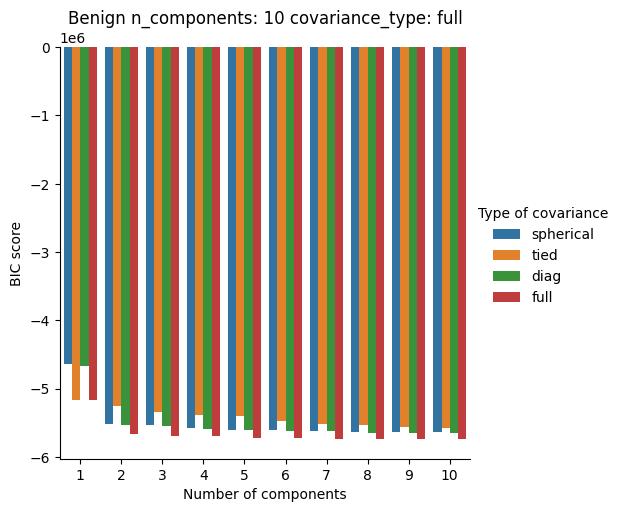

Tipo: 2 = DoS
Melhor modelo: n_componentes: 7 covariance_type: full


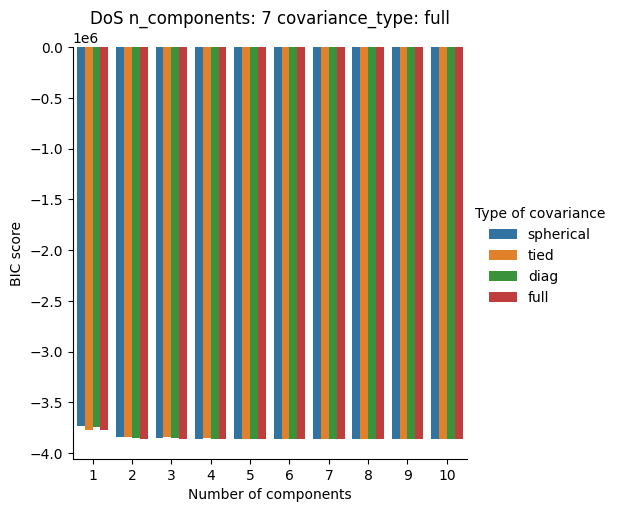

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 6 covariance_type: spherical


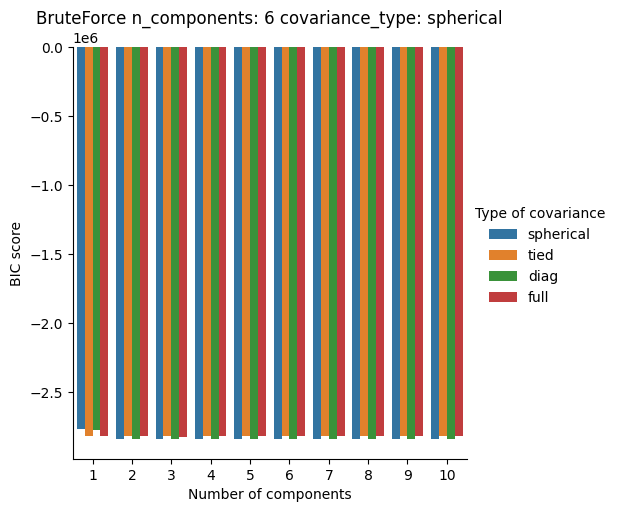

Tipo: 4 = Bot
Melhor modelo: n_componentes: 5 covariance_type: full


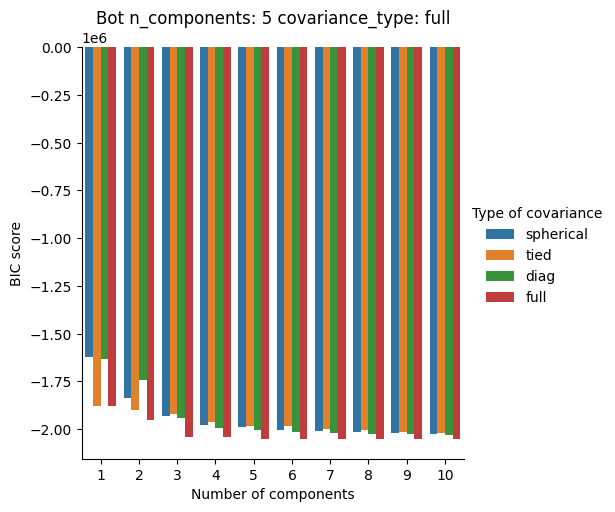

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


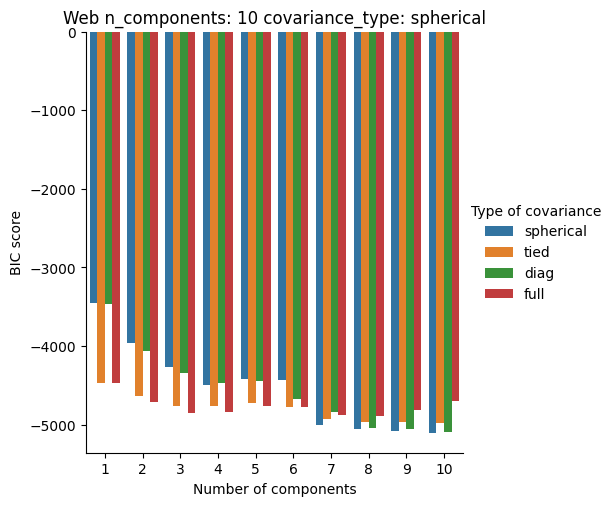

,0,1,2,3,4,5
0,NaN,23.190292,-10.668811,-79.212996,13.237960,1.581916
1,NaN,12.992543,29.643504,-81.202865,-277.189078,1.383621
2,NaN,28.728820,-9.920551,-78.857785,7.959836,3.046238
3,NaN,6.782972,-117.356781,29.303539,-438.261759,4.365500
4,NaN,28.642714,-9.804499,-80.464943,10.141021,2.450472
...,...,...,...,...,...,...
519951,NaN,28.562665,-14.816842,-83.369151,8.444206,2.483863
519952,NaN,17.575648,-178.069441,-106.235417,29.110852,19.140978
519953,NaN,22.298140,-37.749662,-107.474349,12.295017,4.569506
519954,NaN,28.771636,-12.743374,-81.768153,8.404386,2.722674


,0,1,2,3,4,5
0,NaN,22.429186,-36.742567,-106.673828,12.458001,4.313656
1,NaN,21.770307,-11.532052,-78.715639,14.132563,1.577535
2,NaN,28.275262,-8.376087,-77.945777,7.362169,3.293751
3,NaN,25.199090,-15.657994,-87.854901,12.350510,1.036044
4,NaN,18.459690,-24.726023,-80.050662,0.946286,2.133912
...,...,...,...,...,...,...
649942,NaN,28.890523,-10.561429,-80.630786,9.796505,2.535096
649943,NaN,21.701686,-22.207288,-79.696760,2.171333,2.186030
649944,NaN,19.300356,-25.143567,-81.317213,1.538048,1.936924
649945,NaN,7.156974,-112.687233,29.405111,-420.327937,4.263256


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


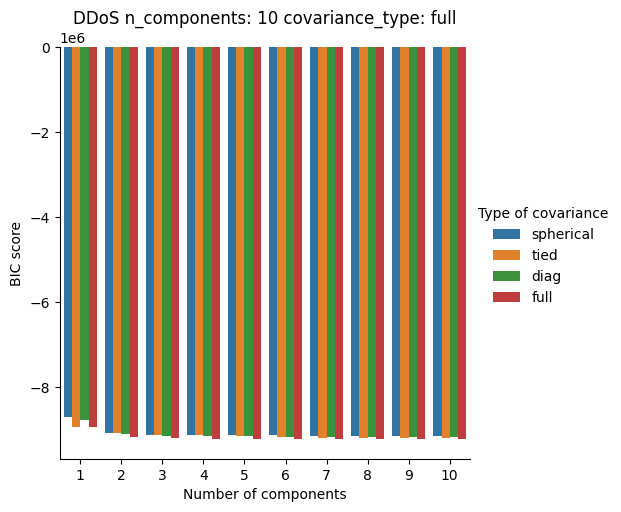

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


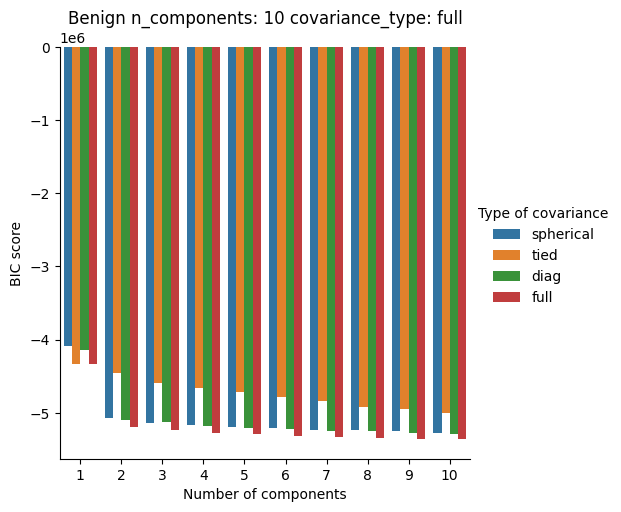

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 7 covariance_type: full


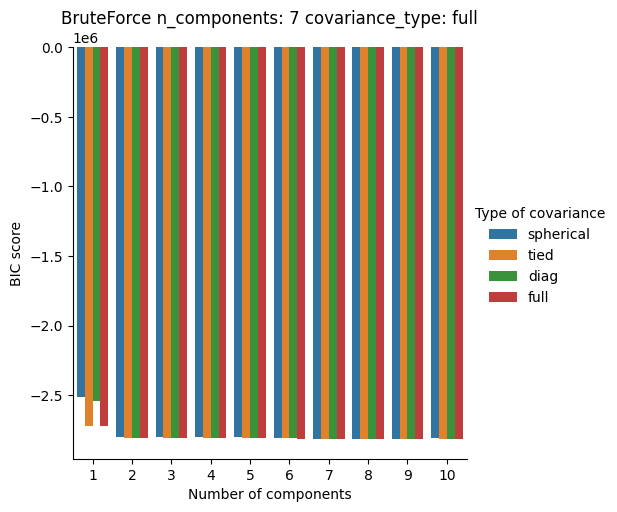

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


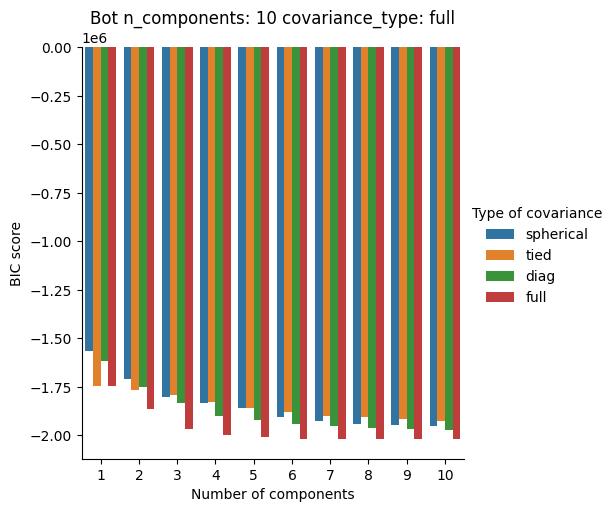

Tipo: 5 = Web
Melhor modelo: n_componentes: 7 covariance_type: full


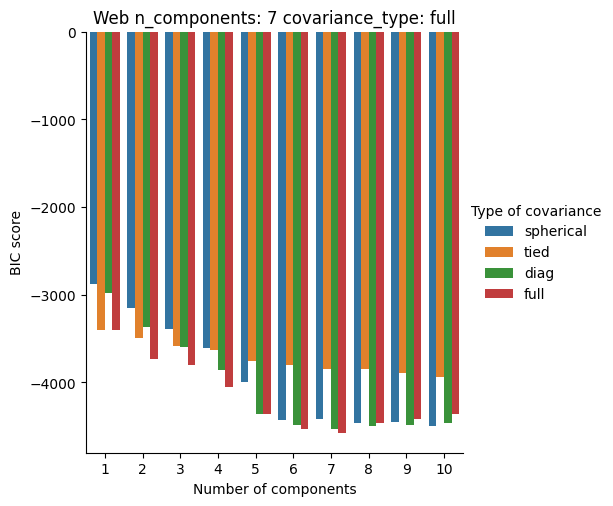

,0,1,2,3,4,5
0,28.689706,19.704653,NaN,-1468.793541,1.375730,13.932521
1,-213.485543,11.091369,NaN,-104.757331,7.734215,-4.026746
2,-52.634266,27.595003,NaN,-258.206147,12.344848,-0.959037
3,-1176.159573,-5.348261,NaN,28.886144,-215.054632,-39.431401
4,-57.579599,27.762187,NaN,-254.562158,12.364555,-0.799715
...,...,...,...,...,...,...
519951,-50.886154,27.569611,NaN,-258.415623,12.478547,-0.106472
519952,-384.862458,4.180478,NaN,-792.460684,29.179043,14.455864
519953,29.119375,20.284526,NaN,-1495.355252,1.952782,13.842535
519954,-60.125304,26.933694,NaN,-280.954124,11.481120,-5.119708


,0,1,2,3,4,5
0,29.102393,20.579910,NaN,-1492.237100,2.067408,13.851221
1,28.422976,19.617566,NaN,-1484.947504,1.273286,13.870582
2,-67.645116,24.978092,NaN,-215.952714,12.714602,3.611860
3,-47.547470,23.926416,NaN,-292.718142,11.778829,-9.106658
4,27.329977,15.970367,NaN,-1414.468666,1.349012,13.918161
...,...,...,...,...,...,...
649942,-59.841620,27.900723,NaN,-254.833140,12.442135,-0.584093
649943,27.880360,16.347286,NaN,-1399.472445,1.094809,14.014611
649944,28.003419,16.074361,NaN,-1413.831899,1.077527,13.917508
649945,-1179.064948,-5.286423,NaN,29.141643,-209.744002,-41.524584


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 9 covariance_type: full


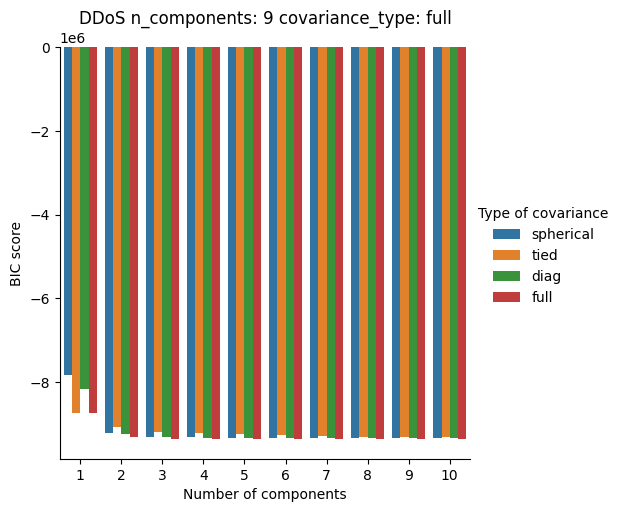

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


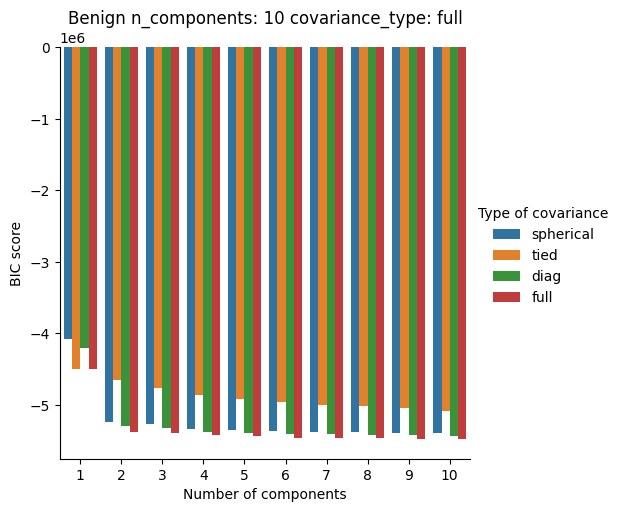

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


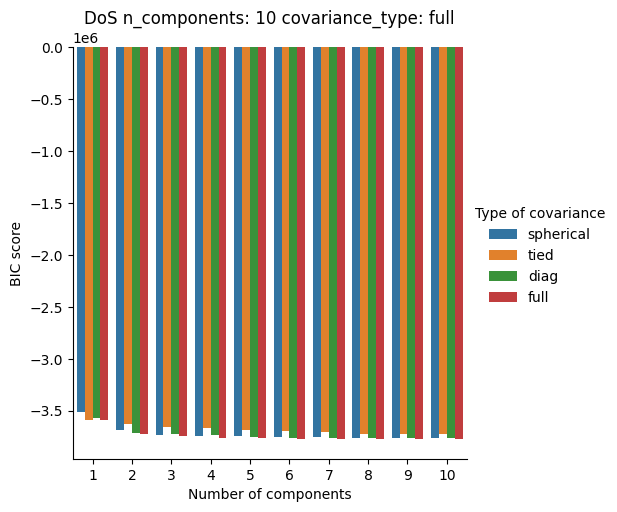

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


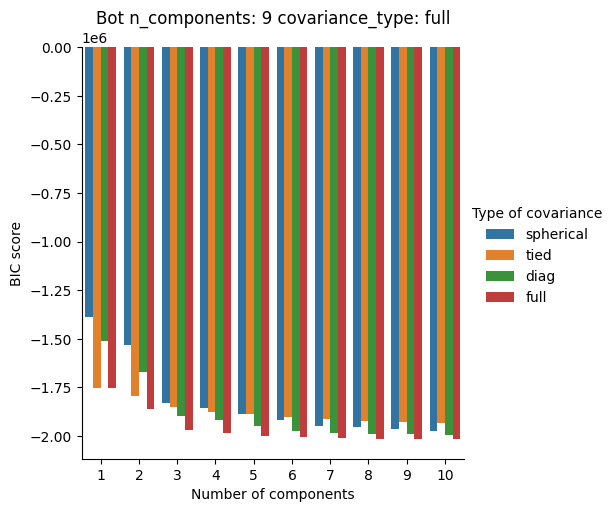

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


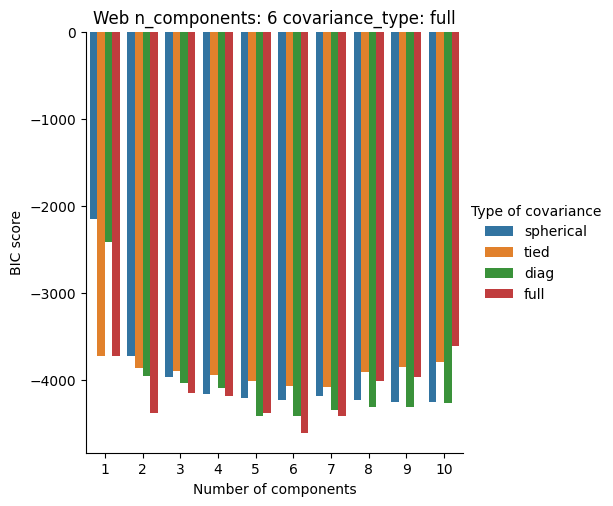

,0,1,2,3,4,5
0,29.286880,7.024145,-32.531977,NaN,-12.862511,4.387004
1,-257.536359,12.701557,29.474145,NaN,-220.773225,-179.113269
2,20.129431,27.485024,-21.772446,NaN,14.947873,8.871934
3,-172.626453,13.953517,13.076253,NaN,-136.410532,-33.925319
4,20.755583,28.263640,-17.732364,NaN,17.282195,7.180794
...,...,...,...,...,...,...
519951,21.456040,28.295442,-19.591693,NaN,17.181023,8.191638
519952,-50.796293,6.699297,-387.953625,NaN,29.054229,18.478013
519953,29.388132,5.859145,-31.298624,NaN,-13.307832,4.259004
519954,21.069793,28.244269,-18.079780,NaN,16.820820,7.999440


,0,1,2,3,4,5
0,29.408591,6.224726,-30.637957,NaN,-13.145211,4.298780
1,29.168901,5.972967,-33.177036,NaN,-13.145951,4.042543
2,17.333328,25.227507,-19.848212,NaN,13.264322,8.463618
3,12.753495,19.836640,-26.508194,NaN,7.668051,10.595826
4,28.700067,6.167355,-29.810689,NaN,-12.819969,4.054215
...,...,...,...,...,...,...
649942,20.100301,28.233410,-17.533949,NaN,17.231802,7.034785
649943,28.580052,6.673845,-29.973337,NaN,-12.867656,4.208495
649944,28.883303,5.870350,-30.436358,NaN,-13.078048,3.865011
649945,-167.859598,13.027461,10.646243,NaN,-134.424768,-70.552903


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


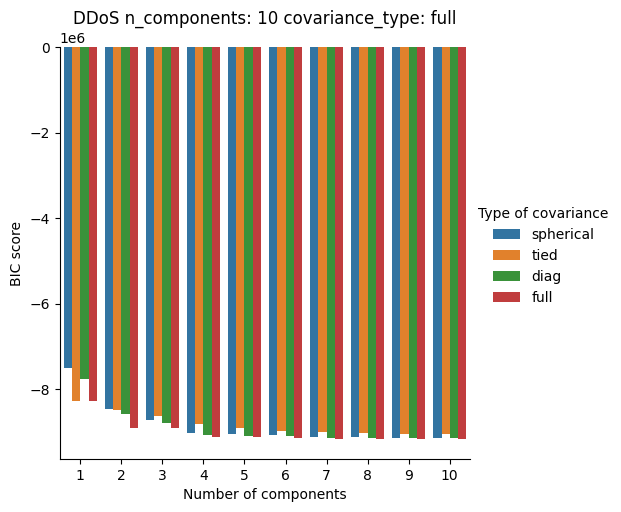

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


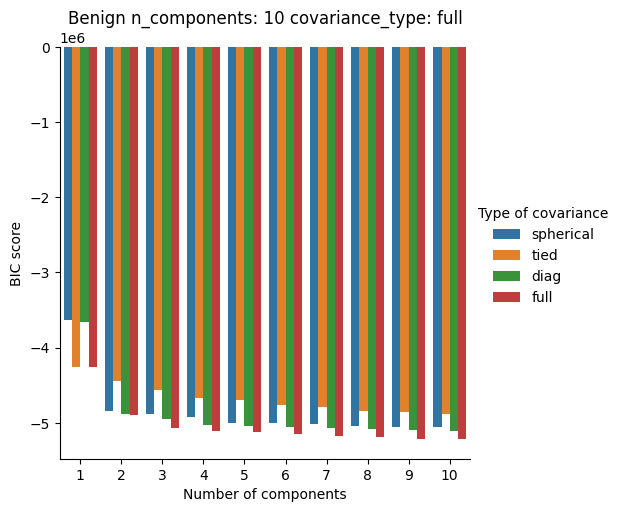

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


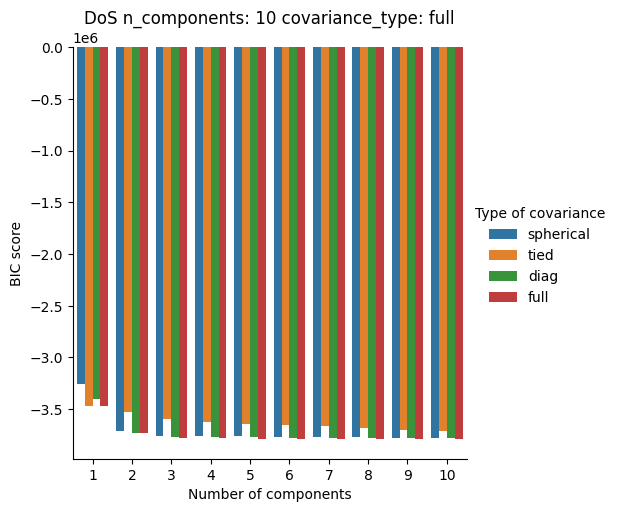

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 8 covariance_type: full


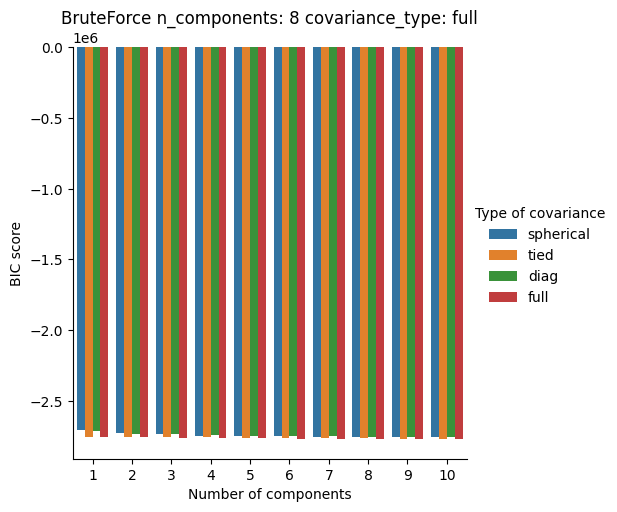

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


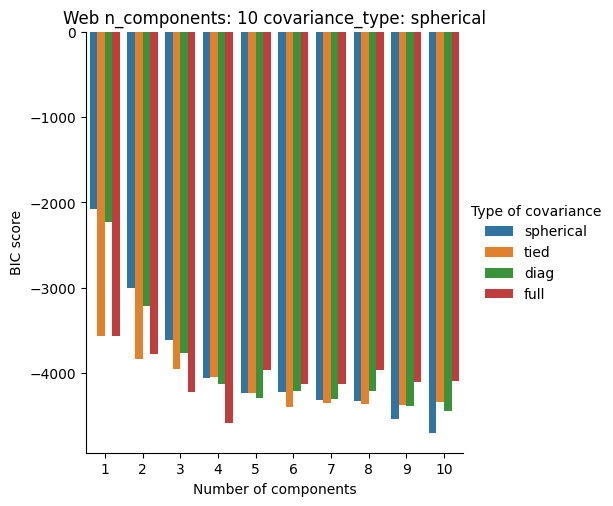

,0,1,2,3,4,5
0,28.334269,13.397364,-392.341827,-647.246617,NaN,-11.144676
1,-244.123292,5.771471,29.635578,17.537695,NaN,-12.140135
2,-0.620844,26.774796,-62.752390,-1974.882262,NaN,7.230803
3,-247.033646,3.718125,-52.950236,27.940608,NaN,-10.959721
4,-2.583243,27.431778,-65.437441,-1842.558474,NaN,7.407506
...,...,...,...,...,...,...
519951,0.031518,26.664976,-52.301225,-1891.895718,NaN,7.146574
519952,-3.856973,13.480569,-129.235178,-1229.413075,NaN,2.564082
519953,29.056487,16.818357,-403.580296,-666.591106,NaN,-12.601472
519954,-3.307168,27.090124,-58.636536,-1846.763793,NaN,7.395368


,0,1,2,3,4,5
0,29.059391,16.686253,-403.772096,-662.856451,NaN,-12.578961
1,28.262992,13.008564,-392.810782,-645.967231,NaN,-11.120613
2,1.359557,23.654312,-78.350268,-1647.472070,NaN,7.099578
3,-10.033276,15.029037,-42.011381,-1368.075041,NaN,4.569861
4,25.663003,6.650055,-364.250110,-645.103464,NaN,-10.178556
...,...,...,...,...,...,...
649942,-4.223442,27.230531,-67.328774,-1860.852065,NaN,7.494971
649943,27.613469,10.086720,-374.161573,-640.159138,NaN,-10.572093
649944,27.632967,10.624755,-374.430187,-642.405724,NaN,-10.620232
649945,-242.160170,3.651913,-50.129153,28.861119,NaN,-10.726274


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


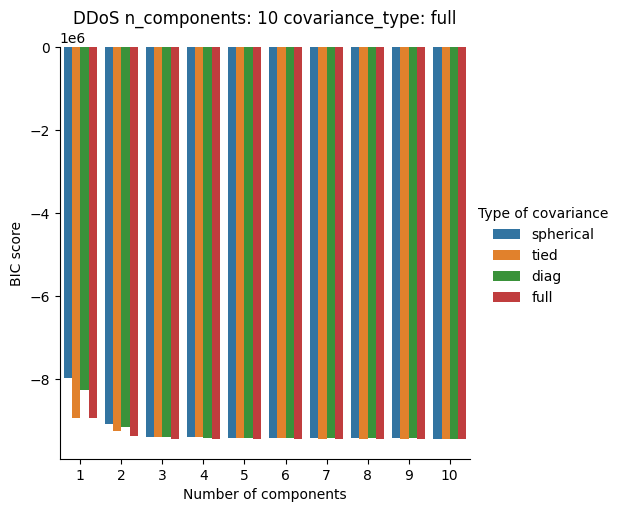

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


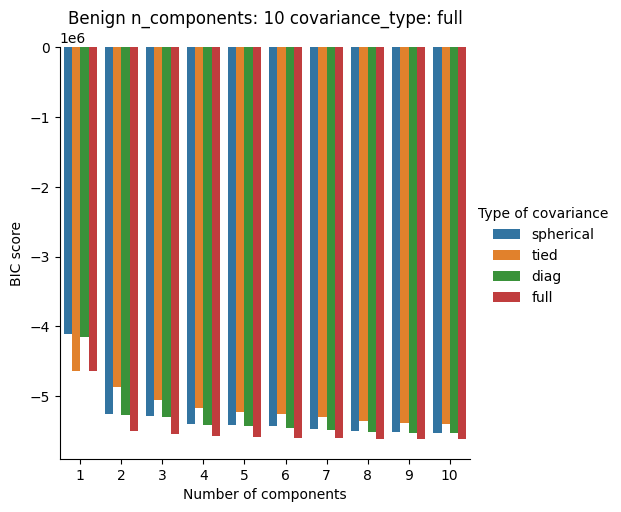

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


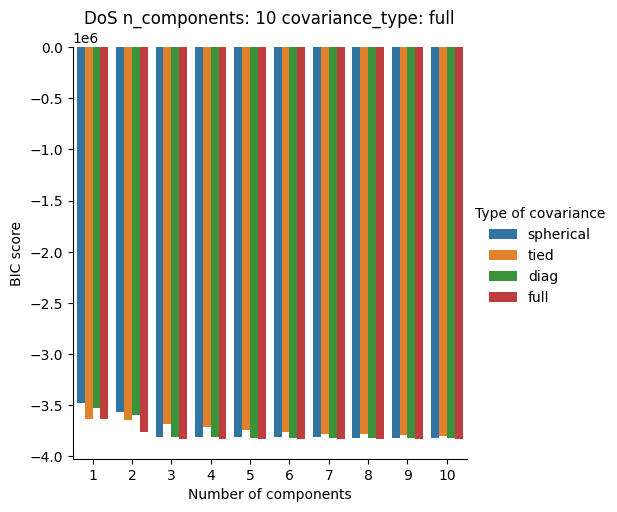

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: diag


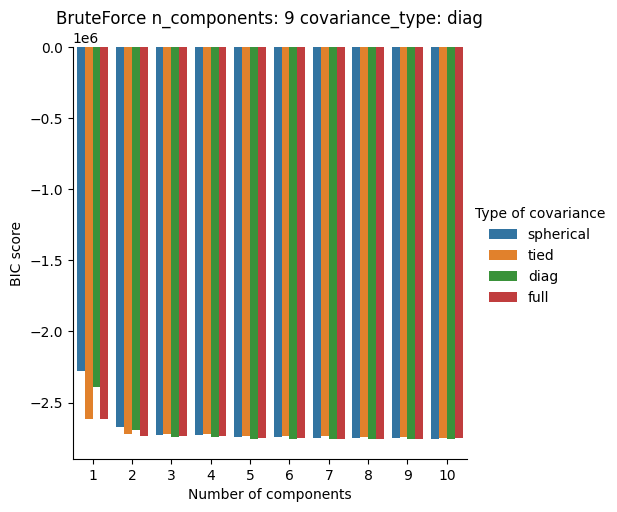

Tipo: 4 = Bot
Melhor modelo: n_componentes: 8 covariance_type: full


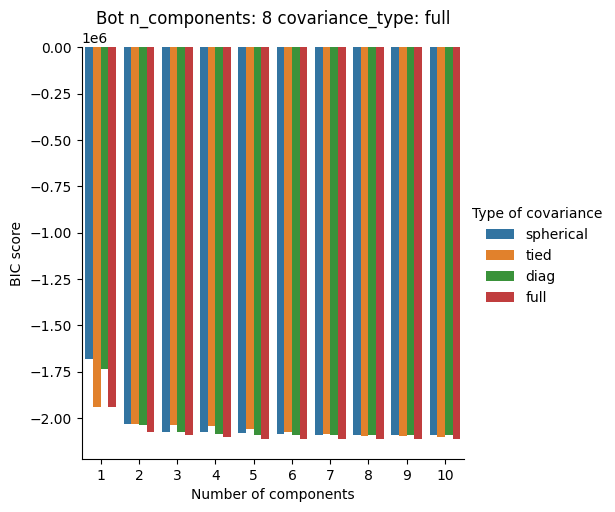

,0,1,2,3,4,5
0,29.454098,7.316394,-204.103667,-457.497482,2.832496,NaN
1,-898.847037,12.251199,29.649049,-12.878796,-700.537664,NaN
2,-7.889508,27.014465,-63.161626,-12.898400,18.507411,NaN
3,-3301.604378,10.059440,-7.678506,28.050099,-489.491075,NaN
4,-36.734306,28.329053,-75.903493,-12.069849,18.976662,NaN
...,...,...,...,...,...,...
519951,-15.657777,27.474854,-65.610694,-12.419883,18.872893,NaN
519952,-6452.055394,18.927561,-6462.163304,-125.938463,29.157815,NaN
519953,29.549878,7.812029,-202.492600,-452.691124,3.229780,NaN
519954,-16.297381,27.813897,-72.530757,-12.385128,18.333373,NaN


,0,1,2,3,4,5
0,29.538715,7.911031,-202.870924,-453.001840,3.411978,NaN
1,29.444864,7.832422,-203.127562,-456.701142,3.056053,NaN
2,-26.241424,28.408416,-72.059074,-11.980826,19.139991,NaN
3,-59.390508,24.147857,-73.426756,-9.888942,16.557920,NaN
4,29.243595,10.669969,-199.052302,-449.222293,5.412813,NaN
...,...,...,...,...,...,...
649942,-38.518730,28.299241,-76.719991,-12.025910,18.926872,NaN
649943,29.372396,9.599557,-200.054839,-450.753449,4.556097,NaN
649944,29.294635,10.302366,-199.399802,-449.755686,5.117900,NaN
649945,-3211.443386,10.432952,-7.975769,28.639847,-520.996074,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)